In [9]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc

In [10]:
# Load dataset
df = pd.read_csv("spambase.data", header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Same split as Problem 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Cell 3: 3.1 - Cross-validation to select k for kNN
# FIXED: precision and recall now computed on validation fold, not training data

k_values = [1, 3, 5, 7, 9, 11]

results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    val_accuracies = []
    val_precisions = []
    val_recalls = []

    for train_idx, val_idx in kf.split(X_train):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        knn.fit(X_tr, y_tr)
        preds = knn.predict(X_val)  # predict on validation fold

        val_accuracies.append(accuracy_score(y_val, preds))
        val_precisions.append(precision_score(y_val, preds))
        val_recalls.append(recall_score(y_val, preds))

    accuracy = np.mean(val_accuracies)
    error = 1 - accuracy
    precision = np.mean(val_precisions)
    recall = np.mean(val_recalls)

    results.append([k, accuracy, error, precision, recall])

cv_table = pd.DataFrame(
    results,
    columns=["k", "Validation Accuracy", "Validation Error", "Precision", "Recall"]
)

print(cv_table)

    k  Validation Accuracy  Validation Error  Precision    Recall
0   1             0.902029          0.097971   0.874148  0.878441
1   3             0.902899          0.097101   0.882030  0.870063
2   5             0.900290          0.099710   0.891344  0.851023
3   7             0.898551          0.101449   0.891166  0.845841
4   9             0.896232          0.103768   0.892472  0.837957
5  11             0.899130          0.100870   0.893002  0.845022


In [12]:
# Select best k
best_k = cv_table.loc[cv_table["Validation Error"].idxmin(), "k"]

print("Best k:", best_k)

Best k: 3


In [13]:
# Cell 5: 3.2 - Compare classifiers on BOTH train and test
# FIXED: now includes precision and recall for both train and test sets

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "LDA": LinearDiscriminantAnalysis(),
    "kNN": KNeighborsClassifier(n_neighbors=best_k)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_error = 1 - train_acc
    test_error = 1 - test_acc

    train_precision = precision_score(y_train, train_pred)
    train_recall = recall_score(y_train, train_pred)

    test_precision = precision_score(y_test, test_pred)
    test_recall = recall_score(y_test, test_pred)

    results.append([
        name,
        train_acc, train_error, train_precision, train_recall,
        test_acc, test_error, test_precision, test_recall
    ])

comparison_table = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy", "Train Error", "Train Precision", "Train Recall",
        "Test Accuracy", "Test Error", "Test Precision", "Test Recall"
    ]
)

print(comparison_table)

                 Model  Train Accuracy  Train Error  Train Precision  \
0  Logistic Regression        0.928986     0.071014         0.927803   
1                  LDA        0.891014     0.108986         0.918298   
2                  kNN        0.950435     0.049565         0.943284   

   Train Recall  Test Accuracy  Test Error  Test Precision  Test Recall  
0      0.888889       0.927889    0.072111        0.930394     0.883260  
1      0.793966       0.884448    0.115552        0.910486     0.784141  
2      0.930096       0.901825    0.098175        0.881432     0.867841  


AUC: 0.9727529563453189


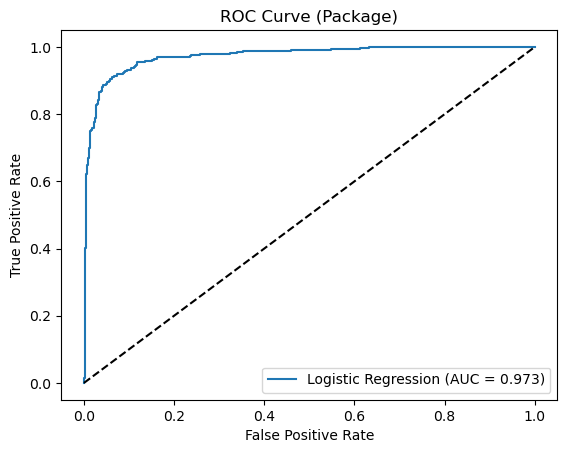

In [15]:
# Cell 6: 3.3 - ROC curve using package
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

probs = log_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %0.3f)" % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Package)")
plt.legend()
plt.show()

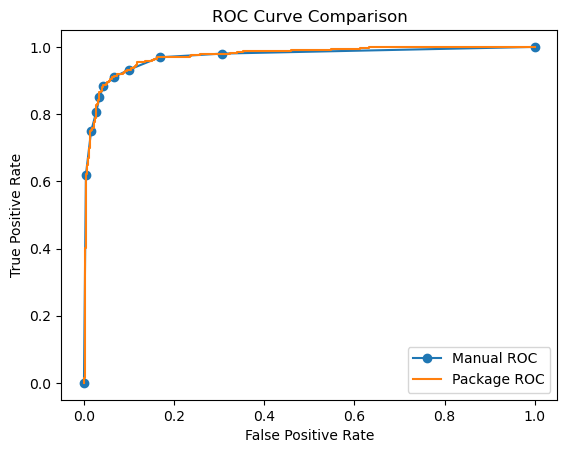

In [16]:
# Cell 7: 3.4 - Manual ROC curve without package
thresholds_manual = np.arange(0, 1.1, 0.1)

manual_tpr = []
manual_fpr = []

for t in thresholds_manual:

    preds = (probs >= t).astype(int)

    TP = np.sum((preds == 1) & (y_test == 1))
    FP = np.sum((preds == 1) & (y_test == 0))
    TN = np.sum((preds == 0) & (y_test == 0))
    FN = np.sum((preds == 0) & (y_test == 1))

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    manual_tpr.append(TPR)
    manual_fpr.append(FPR)

plt.figure()
plt.plot(manual_fpr, manual_tpr, marker='o', label="Manual ROC")
plt.plot(fpr, tpr, label="Package ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()